In [2]:
# ─────────────────────────────────────────────
#  CELL 1 — Imports & Config
# ─────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import seaborn as sns
from pathlib import Path

from prophet import Prophet
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

# ── Plotting style ──────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 10,
})
PALETTE = ["#2563EB", "#16A34A", "#DC2626", "#D97706", "#7C3AED", "#0891B2"]
sns.set_palette(PALETTE)

HORIZON   = 8          # weeks ahead
TEST_WEEKS = HORIZON   # hold-out window
OUTPUT_DIR = Path("/kaggle/working/")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("✅ Imports OK")

✅ Imports OK


In [3]:
# ─────────────────────────────────────────────
#  CELL 2 — Load & Clean Data
# ─────────────────────────────────────────────
demand_raw = pd.read_csv("/kaggle/input/datasets/parthdhanker/data-set-for-ass/demand.csv")
promo_raw  = pd.read_csv("/kaggle/input/datasets/parthdhanker/data-set-for-ass/promotions.csv")

# Fix mixed date formats
demand_raw["date"] = pd.to_datetime(demand_raw["date"], format="mixed", dayfirst=True)
promo_raw["promotion_date"] = pd.to_datetime(
    promo_raw["promotion_date"], format="mixed", dayfirst=True
)

# Winsorise extreme outliers (cap at 99th pct per series)
def winsorise(df):
    cap = df.groupby(["sku", "supermarket"])["demand"].transform(
        lambda x: x.quantile(0.99)
    )
    df = df.copy()
    df["demand"] = df["demand"].clip(upper=cap)
    return df

demand_raw = winsorise(demand_raw)

# Forward-fill + backward-fill missing daily demand within each series
demand_raw = demand_raw.sort_values(["sku", "supermarket", "date"])
demand_raw["demand"] = demand_raw.groupby(["sku", "supermarket"])["demand"].transform(
    lambda x: x.ffill().bfill()
)

# ── Aggregate to weekly (Monday-anchored) ──
weekly = (
    demand_raw
    .groupby(["sku", "supermarket", pd.Grouper(key="date", freq="W-MON")])["demand"]
    .sum()
    .reset_index()
    .rename(columns={"date": "week"})
)

# ── Build promotion flag (weekly) ──
def build_promo_flag(weekly_df, promo_df):
    weekly_df = weekly_df.copy()
    weekly_df["is_promo"] = 0
    for _, row in promo_df.iterrows():
        start = row["promotion_date"]
        end   = start + pd.Timedelta(days=6)
        mask  = (
            (weekly_df["sku"] == row["sku"]) &
            (weekly_df["supermarket"] == row["supermarket"]) &
            (weekly_df["week"] >= start) &
            (weekly_df["week"] <= end)
        )
        weekly_df.loc[mask, "is_promo"] = 1
    return weekly_df

weekly = build_promo_flag(weekly, promo_raw)

SKUS    = sorted(weekly["sku"].unique())
MARKETS = sorted(weekly["supermarket"].unique())
SERIES  = [(s, m) for s in SKUS for m in MARKETS]

print(f"✅ Weekly data: {len(weekly):,} rows | "
      f"{weekly['week'].nunique()} weeks | "
      f"{len(SERIES)} series")
print(f"   Date range : {weekly['week'].min().date()} → {weekly['week'].max().date()}")
print(f"   Missing    : {weekly['demand'].isna().sum()} rows after imputation")
weekly.head()

✅ Weekly data: 1,413 rows | 157 weeks | 9 series
   Date range : 2019-01-07 → 2022-01-03
   Missing    : 0 rows after imputation


,sku,supermarket,week,demand,is_promo
0,Free Range Eggs,DailyNeeds,2019-01-07,484.0,0
1,Free Range Eggs,DailyNeeds,2019-01-14,480.0,0
2,Free Range Eggs,DailyNeeds,2019-01-21,462.0,0
3,Free Range Eggs,DailyNeeds,2019-01-28,465.0,0
4,Free Range Eggs,DailyNeeds,2019-02-04,468.0,0


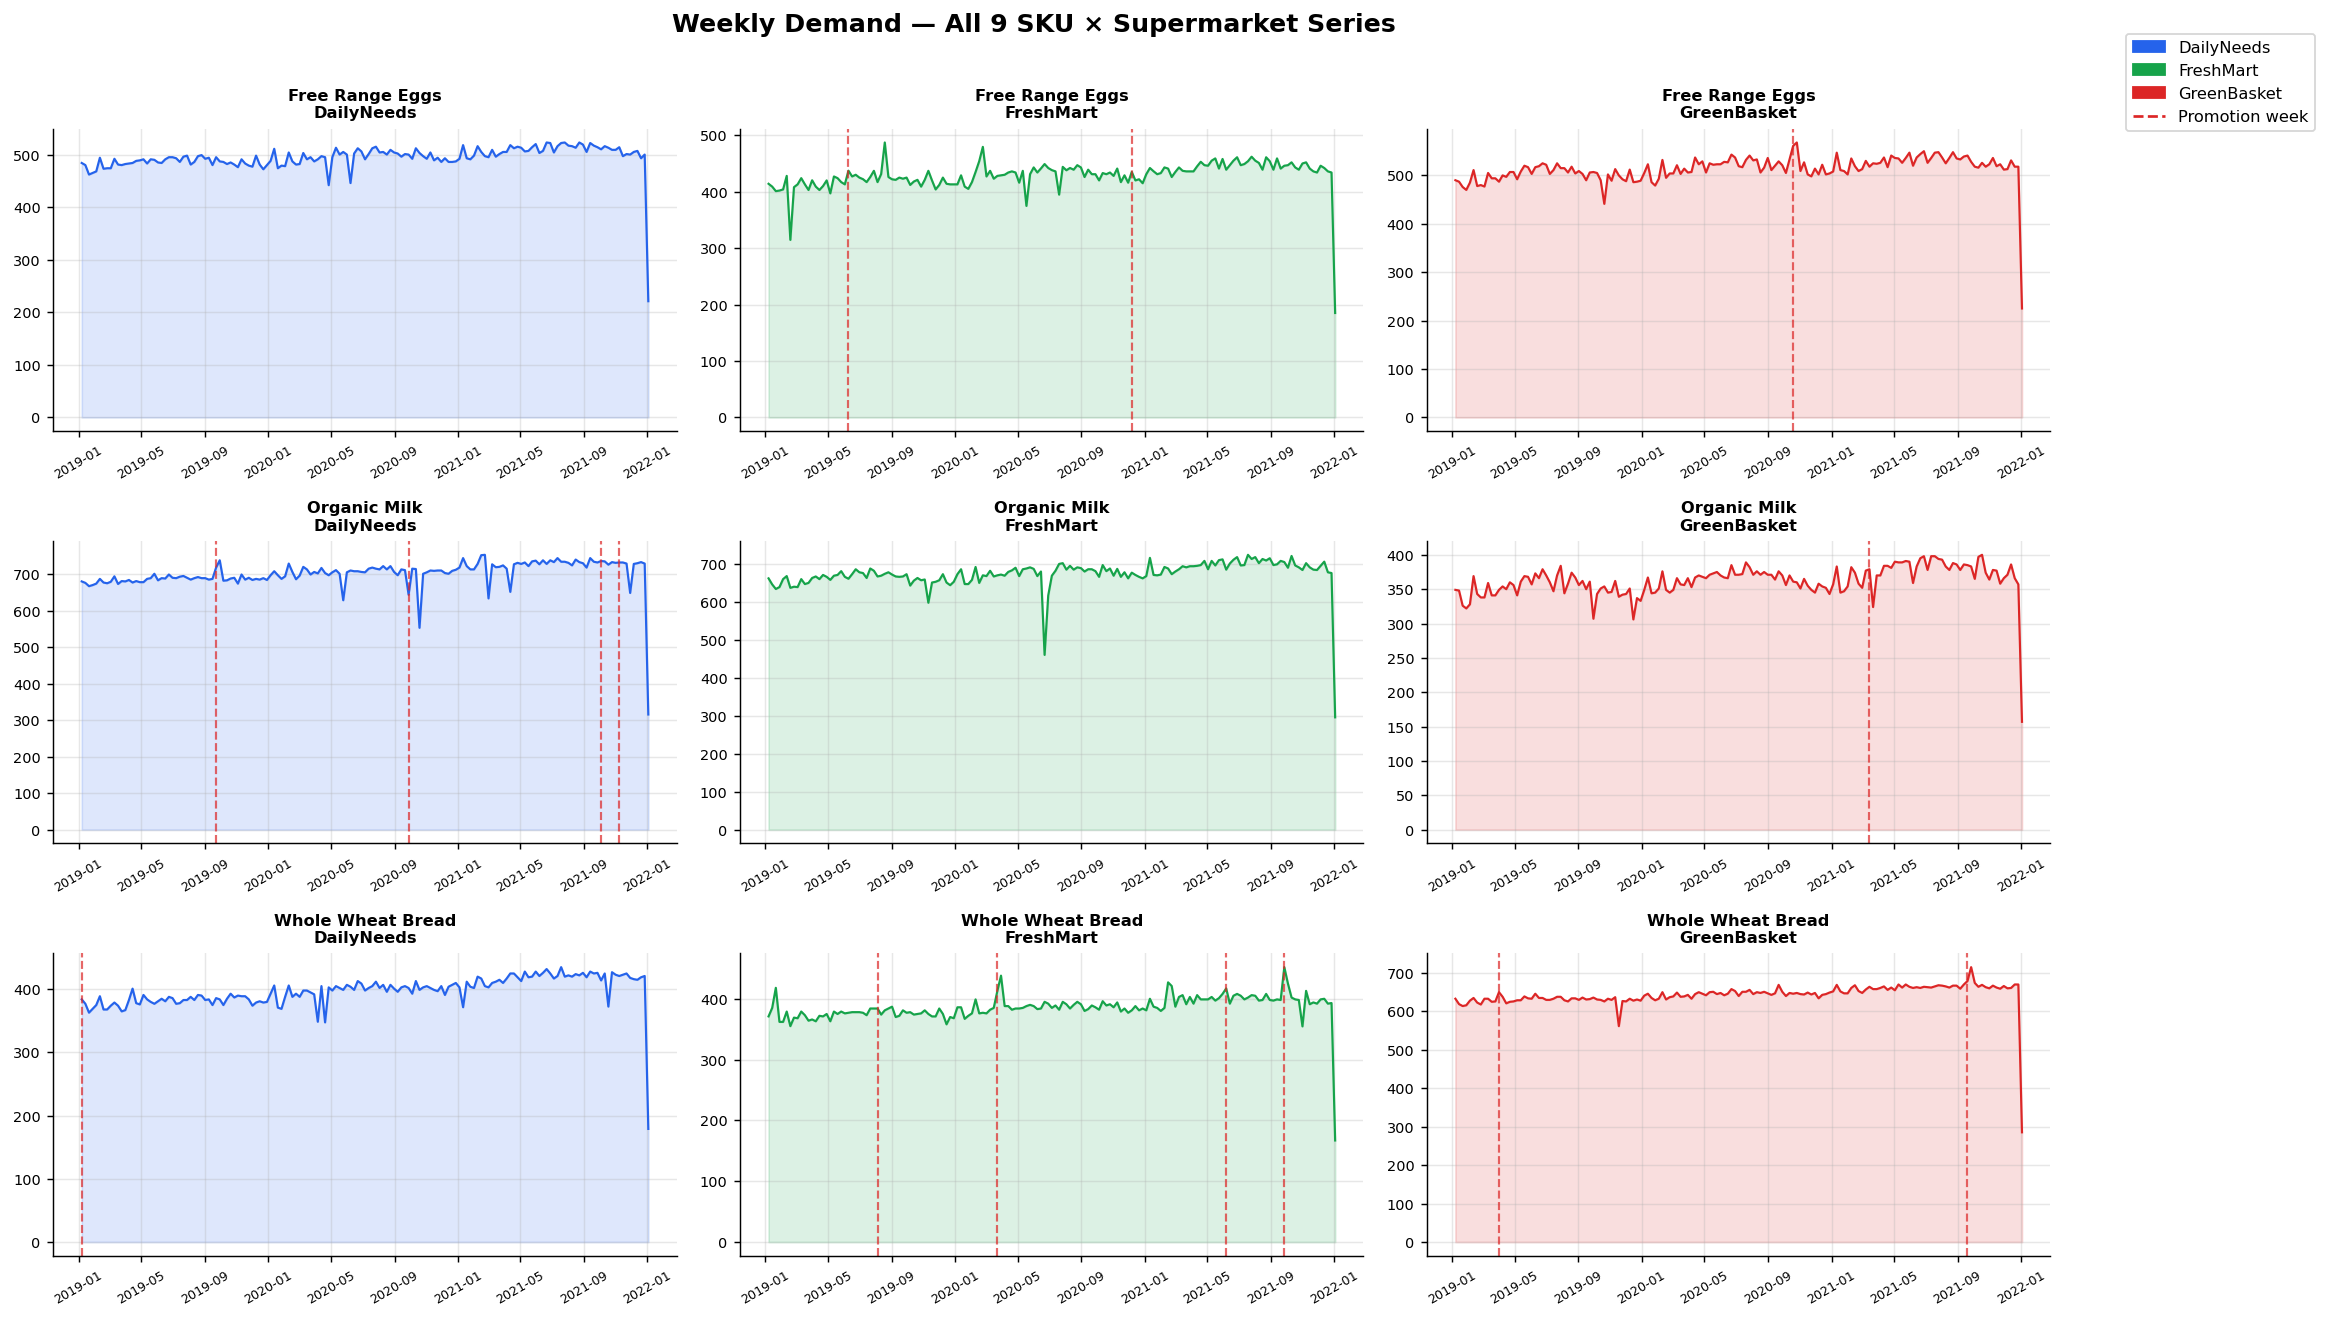

✅ Fig 1 saved


In [4]:
# ─────────────────────────────────────────────
#  CELL 3 — EDA: Demand Time Series (all 9 series)
# ─────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 10), sharey=False)
fig.suptitle("Weekly Demand — All 9 SKU × Supermarket Series", fontsize=14, fontweight="bold", y=1.01)

color_map = dict(zip(MARKETS, PALETTE[:3]))

for ax, (sku, market) in zip(axes.flatten(), SERIES):
    s = weekly[(weekly["sku"] == sku) & (weekly["supermarket"] == market)]
    promo_weeks = s[s["is_promo"] == 1]["week"]

    ax.fill_between(s["week"], s["demand"], alpha=0.15, color=color_map[market])
    ax.plot(s["week"], s["demand"], lw=1.2, color=color_map[market])

    # Mark promo weeks
    for pw in promo_weeks:
        ax.axvline(pw, color="#DC2626", lw=1.2, alpha=0.7, linestyle="--")

    ax.set_title(f"{sku}\n{market}", fontsize=9, fontweight="bold")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30, labelsize=7)
    ax.yaxis.set_tick_params(labelsize=8)

legend_handles = [mpatches.Patch(color=color_map[m], label=m) for m in MARKETS]
legend_handles.append(Line2D([0], [0], color="#DC2626", lw=1.5, linestyle="--", label="Promotion week"))
fig.legend(handles=legend_handles, loc="upper right", bbox_to_anchor=(1.12, 1.0), fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "01_time_series_all.png", bbox_inches="tight")
plt.show()
print("✅ Fig 1 saved")

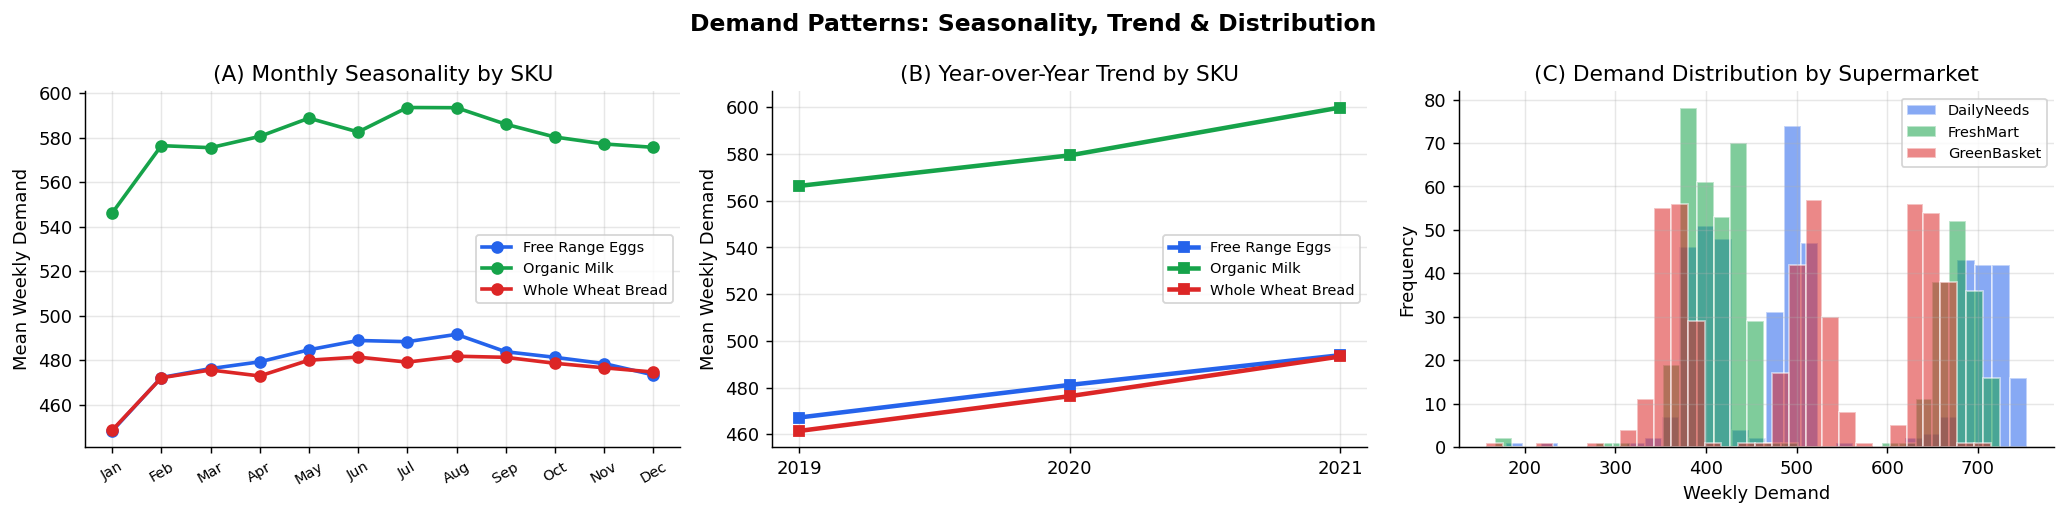

✅ Fig 2 saved


In [5]:
# ─────────────────────────────────────────────
#  CELL 4 — EDA: Seasonality & Trend
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Demand Patterns: Seasonality, Trend & Distribution", fontsize=13, fontweight="bold")

# ── (A) Monthly seasonality ──
weekly["month"] = weekly["week"].dt.month
monthly_avg = weekly.groupby(["month", "sku"])["demand"].mean().reset_index()
month_labels = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

ax = axes[0]
for i, sku in enumerate(SKUS):
    d = monthly_avg[monthly_avg["sku"] == sku]
    ax.plot(d["month"], d["demand"], marker="o", lw=2, color=PALETTE[i], label=sku)
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels, rotation=30, fontsize=8)
ax.set_title("(A) Monthly Seasonality by SKU")
ax.set_ylabel("Mean Weekly Demand")
ax.legend(fontsize=8)

# ── (B) Year-over-year trend ──
weekly["year"] = weekly["week"].dt.year
yearly_avg = weekly[weekly["year"] < 2022].groupby(["year","sku"])["demand"].mean().reset_index()

ax = axes[1]
for i, sku in enumerate(SKUS):
    d = yearly_avg[yearly_avg["sku"] == sku]
    ax.plot(d["year"], d["demand"], marker="s", lw=2.5, color=PALETTE[i], label=sku)
ax.set_title("(B) Year-over-Year Trend by SKU")
ax.set_ylabel("Mean Weekly Demand")
ax.set_xticks([2019, 2020, 2021])
ax.legend(fontsize=8)

# ── (C) Demand distribution by supermarket ──
ax = axes[2]
for i, market in enumerate(MARKETS):
    d = weekly[weekly["supermarket"] == market]["demand"]
    ax.hist(d, bins=30, alpha=0.55, color=PALETTE[i], label=market, edgecolor="white")
ax.set_title("(C) Demand Distribution by Supermarket")
ax.set_xlabel("Weekly Demand")
ax.set_ylabel("Frequency")
ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "02_eda_patterns.png", bbox_inches="tight")
plt.show()
print("✅ Fig 2 saved")

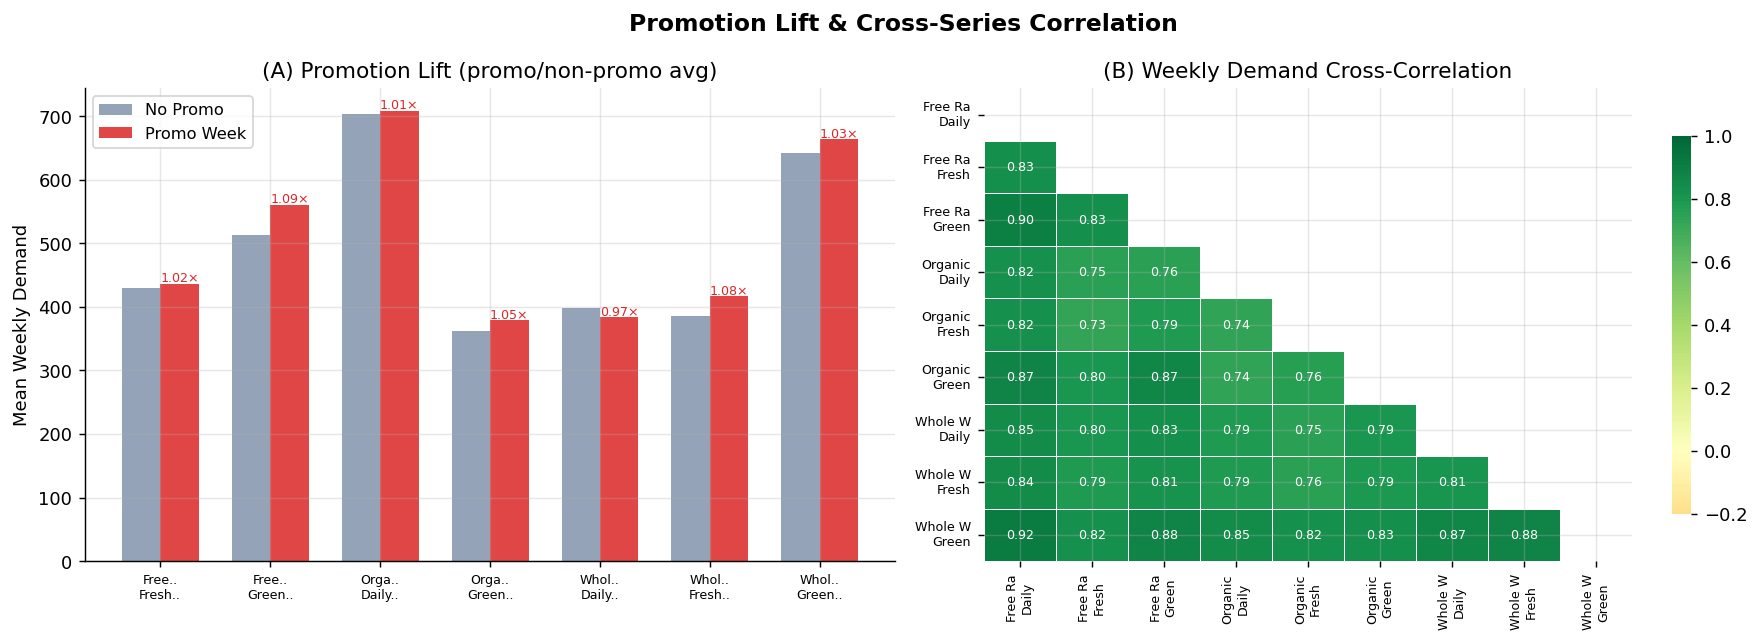

✅ Fig 3 saved


In [6]:
# ─────────────────────────────────────────────
#  CELL 5 — EDA: Promotion Lift & Correlation Heatmap
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Promotion Lift & Cross-Series Correlation", fontsize=13, fontweight="bold")

# ── (A) Promo vs non-promo demand ──
ax = axes[0]
promo_compare = []
for sku, market in SERIES:
    s = weekly[(weekly["sku"] == sku) & (weekly["supermarket"] == market)]
    promo_mean    = s[s["is_promo"] == 1]["demand"].mean()
    no_promo_mean = s[s["is_promo"] == 0]["demand"].mean()
    if not np.isnan(promo_mean):
        promo_compare.append({
            "label": f"{sku[:4]}..\n{market[:5]}..",
            "no_promo": no_promo_mean,
            "promo": promo_mean,
            "lift": promo_mean / no_promo_mean,
        })

pc = pd.DataFrame(promo_compare)
x = np.arange(len(pc))
w = 0.35
ax.bar(x - w/2, pc["no_promo"], w, label="No Promo",  color="#94A3B8")
ax.bar(x + w/2, pc["promo"],    w, label="Promo Week", color="#DC2626", alpha=0.85)
for i, row in pc.iterrows():
    ax.text(i + w/2, row["promo"] + 3, f"{row['lift']:.2f}×", ha="center", fontsize=7, color="#DC2626")
ax.set_xticks(x)
ax.set_xticklabels(pc["label"], fontsize=7)
ax.set_ylabel("Mean Weekly Demand")
ax.set_title("(A) Promotion Lift (promo/non-promo avg)")
ax.legend(fontsize=9)

# ── (B) Cross-series correlation heatmap ──
ax = axes[1]
pivot = weekly.pivot_table(index="week", columns=["sku","supermarket"], values="demand")
pivot.columns = [f"{s[:7]}\n{m[:5]}" for s, m in pivot.columns]
corr = pivot.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, ax=ax, mask=mask, annot=True, fmt=".2f",
    cmap="RdYlGn", center=0, vmin=-0.2, vmax=1,
    linewidths=0.5, annot_kws={"size": 7},
    cbar_kws={"shrink": 0.8}
)
ax.set_title("(B) Weekly Demand Cross-Correlation")
ax.tick_params(labelsize=7)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "03_promo_and_corr.png", bbox_inches="tight")
plt.show()
print("✅ Fig 3 saved")

In [7]:
# ─────────────────────────────────────────────
#  CELL 6 — Train/Test Split Utility
# ─────────────────────────────────────────────
def split_series(series_df):
    """Split a single series into train / test (last TEST_WEEKS weeks)."""
    s = series_df.sort_values("week").reset_index(drop=True)
    cutoff = s["week"].iloc[-(TEST_WEEKS + 1)]
    train = s[s["week"] <= cutoff].copy()
    test  = s[s["week"] >  cutoff].copy()
    return train, test

def wape(actual, predicted):
    """Weighted Absolute Percentage Error — robust to near-zero values."""
    actual    = np.array(actual,    dtype=float)
    predicted = np.array(predicted, dtype=float)
    return np.sum(np.abs(actual - predicted)) / np.sum(np.abs(actual))

print("✅ Utility functions defined")

✅ Utility functions defined


In [8]:
# ─────────────────────────────────────────────
#  CELL 7 — MODEL 1: Seasonal Naive (baseline)
# ─────────────────────────────────────────────
# Forecast = demand for the same week in the previous year (lag-52)

def seasonal_naive_forecast(train, horizon=HORIZON):
    """
    For each of the next `horizon` weeks, use the demand value from
    the same calendar week one year prior.
    Returns a list of `horizon` forecasts.
    """
    train = train.sort_values("week").reset_index(drop=True)
    last_date = train["week"].iloc[-1]
    preds = []

    for h in range(1, horizon + 1):
        target_date = last_date + pd.Timedelta(weeks=h)
        same_wk_last_yr = target_date - pd.Timedelta(weeks=52)
        # Find closest available historical week
        diffs = (train["week"] - same_wk_last_yr).abs()
        idx   = diffs.idxmin()
        preds.append(train.loc[idx, "demand"])

    return preds


results_naive = {}

for sku, market in SERIES:
    s = weekly[(weekly["sku"] == sku) & (weekly["supermarket"] == market)]
    train, test = split_series(s)
    preds = seasonal_naive_forecast(train)
    # Align length
    n     = min(len(preds), len(test))
    score = wape(test["demand"].values[:n], preds[:n])
    results_naive[(sku, market)] = {
        "preds" : preds[:n],
        "actual": test["demand"].values[:n],
        "wape"  : score,
        "test"  : test.iloc[:n],
    }

naive_wape = np.mean([v["wape"] for v in results_naive.values()])
print(f"✅ Seasonal Naive — Mean WAPE across 9 series: {naive_wape:.3f} ({naive_wape*100:.1f}%)")
for (sku, market), v in results_naive.items():
    print(f"   {sku[:20]:20s} | {market:12s} | WAPE={v['wape']*100:.1f}%")

✅ Seasonal Naive — Mean WAPE across 9 series: 0.106 (10.6%)
   Free Range Eggs      | DailyNeeds   | WAPE=9.5%
   Free Range Eggs      | FreshMart    | WAPE=11.1%
   Free Range Eggs      | GreenBasket  | WAPE=9.8%
   Organic Milk         | DailyNeeds   | WAPE=11.2%
   Organic Milk         | FreshMart    | WAPE=9.9%
   Organic Milk         | GreenBasket  | WAPE=11.9%
   Whole Wheat Bread    | DailyNeeds   | WAPE=11.2%
   Whole Wheat Bread    | FreshMart    | WAPE=10.3%
   Whole Wheat Bread    | GreenBasket  | WAPE=10.2%


In [9]:
# ─────────────────────────────────────────────
#  CELL 8 — MODEL 2: Prophet (per-series)
# ─────────────────────────────────────────────
def prophet_forecast(train, test, horizon=HORIZON):
    """
    Fit Prophet with yearly seasonality + promotion regressor.
    Returns predictions aligned to `test` dates.
    """
    df_train = train.rename(columns={"week": "ds", "demand": "y"})[["ds","y","is_promo"]]

    m = Prophet(
        yearly_seasonality   = True,
        weekly_seasonality   = False,   # data is already weekly
        daily_seasonality    = False,
        changepoint_prior_scale = 0.05, # mild — trend is slow
        seasonality_prior_scale = 10.0,
    )
    m.add_regressor("is_promo")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        m.fit(df_train)

    # Build future frame for test weeks
    future = test.rename(columns={"week": "ds"})[["ds","is_promo"]]
    forecast = m.predict(future)
    preds = forecast["yhat"].clip(lower=0).values
    return preds


results_prophet = {}

for i, (sku, market) in enumerate(SERIES):
    s = weekly[(weekly["sku"] == sku) & (weekly["supermarket"] == market)]
    train, test = split_series(s)
    preds = prophet_forecast(train, test)
    n     = min(len(preds), len(test))
    score = wape(test["demand"].values[:n], preds[:n])
    results_prophet[(sku, market)] = {
        "preds" : preds[:n],
        "actual": test["demand"].values[:n],
        "wape"  : score,
        "test"  : test.iloc[:n],
    }
    print(f"  [{i+1}/9] {sku[:20]:20s} | {market:12s} | WAPE={score*100:.1f}%")

prophet_wape = np.mean([v["wape"] for v in results_prophet.values()])
print(f"\n✅ Prophet — Mean WAPE across 9 series: {prophet_wape:.3f} ({prophet_wape*100:.1f}%)")

08:47:58 - cmdstanpy - INFO - Chain [1] start processing
08:47:58 - cmdstanpy - INFO - Chain [1] done processing
08:47:59 - cmdstanpy - INFO - Chain [1] start processing
08:47:59 - cmdstanpy - INFO - Chain [1] done processing
08:47:59 - cmdstanpy - INFO - Chain [1] start processing
08:47:59 - cmdstanpy - INFO - Chain [1] done processing


  [1/9] Free Range Eggs      | DailyNeeds   | WAPE=9.5%
  [2/9] Free Range Eggs      | FreshMart    | WAPE=9.1%
  [3/9] Free Range Eggs      | GreenBasket  | WAPE=8.8%


08:47:59 - cmdstanpy - INFO - Chain [1] start processing
08:47:59 - cmdstanpy - INFO - Chain [1] done processing
08:47:59 - cmdstanpy - INFO - Chain [1] start processing
08:47:59 - cmdstanpy - INFO - Chain [1] done processing
08:47:59 - cmdstanpy - INFO - Chain [1] start processing
08:47:59 - cmdstanpy - INFO - Chain [1] done processing


  [4/9] Organic Milk         | DailyNeeds   | WAPE=10.7%
  [5/9] Organic Milk         | FreshMart    | WAPE=9.7%
  [6/9] Organic Milk         | GreenBasket  | WAPE=11.1%


08:47:59 - cmdstanpy - INFO - Chain [1] start processing
08:47:59 - cmdstanpy - INFO - Chain [1] done processing
08:47:59 - cmdstanpy - INFO - Chain [1] start processing
08:47:59 - cmdstanpy - INFO - Chain [1] done processing
08:47:59 - cmdstanpy - INFO - Chain [1] start processing
08:47:59 - cmdstanpy - INFO - Chain [1] done processing


  [7/9] Whole Wheat Bread    | DailyNeeds   | WAPE=8.5%
  [8/9] Whole Wheat Bread    | FreshMart    | WAPE=9.2%
  [9/9] Whole Wheat Bread    | GreenBasket  | WAPE=8.4%

✅ Prophet — Mean WAPE across 9 series: 0.094 (9.4%)


In [10]:
# ─────────────────────────────────────────────
#  CELL 9 — MODEL 3: LightGBM (direct multi-step)
# ─────────────────────────────────────────────
# One model per horizon step (h=1 … HORIZON).
# Features: calendar + promo + lags + rolling means + entity dummies.

def build_lgbm_features(weekly_df):
    """
    Create a feature-rich DataFrame from the pooled weekly data.
    All 9 series are stacked so the model shares information across them.
    NOTE: sku / supermarket must still be raw columns when this is called.
    """
    # Preserve any extra columns (e.g. target_h* added before this call)
    extra_cols = [c for c in weekly_df.columns
                  if c not in ["sku","supermarket","week","demand","is_promo"]]

    df = weekly_df.sort_values(["sku","supermarket","week"]).copy()

    # ── Calendar features ──
    df["week_of_year"] = df["week"].dt.isocalendar().week.astype(int)
    df["month"]        = df["week"].dt.month
    df["quarter"]      = df["week"].dt.quarter
    df["year"]         = df["week"].dt.year
    t0 = df["week"].min()
    df["t_idx"] = ((df["week"] - t0) / pd.Timedelta(weeks=1)).astype(int)

    # ── Lag features (per series) ──
    for lag in [4, 8, 13, 26, 52]:
        df[f"lag_{lag}"] = df.groupby(["sku","supermarket"])["demand"].shift(lag)

    # ── Rolling statistics ──
    for w in [4, 8, 13]:
        df[f"roll_mean_{w}"] = (
            df.groupby(["sku","supermarket"])["demand"]
            .transform(lambda x: x.shift(1).rolling(w, min_periods=1).mean())
        )
        df[f"roll_std_{w}"] = (
            df.groupby(["sku","supermarket"])["demand"]
            .transform(lambda x: x.shift(1).rolling(w, min_periods=1).std())
        )

    # ── Entity dummies ──
    df = pd.get_dummies(df, columns=["sku","supermarket"], drop_first=False)

    # Convert bool dummies to int
    bool_cols = df.select_dtypes(include="bool").columns.tolist()
    df[bool_cols] = df[bool_cols].astype(int)

    return df


def train_lgbm_direct(weekly_df, horizon=HORIZON):
    """
    Train HORIZON separate LightGBM models (direct multi-step strategy).
    Targets are shifted BEFORE dummifying so we still have sku/supermarket for groupby.
    Returns dict: h → (fitted model, feature_cols)
    """
    # Step 1: compute per-horizon targets while sku/supermarket columns still exist
    base = weekly_df.sort_values(["sku", "supermarket", "week"]).copy()
    for h in range(1, horizon + 1):
        base[f"target_h{h}"] = base.groupby(["sku", "supermarket"])["demand"].shift(-h)

    # Step 2: now build features (this dummifies sku/supermarket)
    df = build_lgbm_features(base)

    # Convert bool columns to int
    bool_cols = df.select_dtypes(include="bool").columns.tolist()
    df[bool_cols] = df[bool_cols].astype(int)

    target_cols  = [f"target_h{h}" for h in range(1, horizon + 1)]
    exclude_cols = {"week", "demand"} | set(target_cols)
    feature_cols = [c for c in df.columns if c not in exclude_cols
                    and df[c].dtype in [np.float64, np.int64, np.int32, np.int8, np.uint8]]

    models = {}
    for h in range(1, horizon + 1):
        target = f"target_h{h}"
        mask   = df[target].notna()
        X      = df.loc[mask, feature_cols].fillna(0)
        y      = df.loc[mask, target]

        model = lgb.LGBMRegressor(
            n_estimators      = 400,
            learning_rate     = 0.05,
            num_leaves        = 31,
            min_child_samples = 10,
            subsample         = 0.8,
            colsample_bytree  = 0.8,
            random_state      = 42,
            verbose           = -1,
        )
        model.fit(X, y)
        models[h] = (model, feature_cols)

    return models


def predict_lgbm(models, df_feat, test_weeks_index):
    """
    For each test row index, predict across all horizons.
    Returns (n_test,) array.
    """
    preds = []
    feature_cols = models[1][1]
    for idx in test_weeks_index:
        row_preds = []
        for h in range(1, HORIZON + 1):
            if h in models:
                model, fcols = models[h]
                X = df_feat.loc[[idx], fcols].fillna(0)
                p = model.predict(X)[0]
                row_preds.append(max(0, p))
        preds.append(row_preds)
    # preds is (n_test_rows, HORIZON); we want 1 prediction per test week
    # Each test week corresponds to a 1-step forecast from the week before it
    return preds


# ── Determine cutoff week (same split as other models) ──
all_cutoffs = {}
for sku, market in SERIES:
    s = weekly[(weekly["sku"] == sku) & (weekly["supermarket"] == market)]
    train, test = split_series(s)
    all_cutoffs[(sku, market)] = (train["week"].max(), test["week"].tolist())

global_cutoff = min(v[0] for v in all_cutoffs.values())

# ── Train on train slice (pooled across all series) ──
weekly_train = weekly[weekly["week"] <= global_cutoff].copy()
print("Training 8 LightGBM models (one per horizon step)...")
lgb_models = train_lgbm_direct(weekly_train)

# ── Build full feature df for inference ──
# We need to build features on the FULL weekly (so lag features are correct)
# then filter to test weeks for scoring
feat_df_full = build_lgbm_features(weekly).reset_index(drop=True)
feature_cols = lgb_models[1][1]

results_lgbm = {}
for sku, market in SERIES:
    sku_col = f"sku_{sku}"
    mkt_col = f"supermarket_{market}"

    # For each test week, use h=1..H models to produce direct forecasts
    # We use the last train row as the "current" observation and predict h=1..H ahead
    series_feat = feat_df_full[
        (feat_df_full[sku_col] == 1) & (feat_df_full[mkt_col] == 1)
    ].copy().sort_values("week").reset_index(drop=True)

    # Last train row = row just before the test window
    last_train_row = series_feat[series_feat["week"] <= global_cutoff].iloc[[-1]]
    test_rows      = series_feat[series_feat["week"] >  global_cutoff].head(HORIZON)

    if len(test_rows) == 0:
        continue

    # Direct forecasts: model_h predicts demand h weeks ahead from last_train_row
    preds = []
    for h in range(1, HORIZON + 1):
        if h not in lgb_models:
            break
        model, fcols = lgb_models[h]
        X = last_train_row[fcols].fillna(0)
        p = model.predict(X)[0]
        preds.append(max(0.0, p))

    actual = test_rows["demand"].values
    n      = min(len(preds), len(actual))
    score  = wape(actual[:n], preds[:n])
    results_lgbm[(sku, market)] = {
        "preds" : np.array(preds[:n]),
        "actual": actual[:n],
        "wape"  : score,
        "weeks" : test_rows["week"].values[:n],
    }
    print(f"  {sku[:20]:20s} | {market:12s} | WAPE={score*100:.1f}%")

lgbm_wape = np.mean([v["wape"] for v in results_lgbm.values()])
print(f"\n✅ LightGBM — Mean WAPE across 9 series: {lgbm_wape:.3f} ({lgbm_wape*100:.1f}%)")

Training 8 LightGBM models (one per horizon step)...
  Free Range Eggs      | DailyNeeds   | WAPE=9.1%
  Free Range Eggs      | FreshMart    | WAPE=9.4%
  Free Range Eggs      | GreenBasket  | WAPE=8.7%
  Organic Milk         | DailyNeeds   | WAPE=9.5%
  Organic Milk         | FreshMart    | WAPE=10.0%
  Organic Milk         | GreenBasket  | WAPE=10.6%
  Whole Wheat Bread    | DailyNeeds   | WAPE=8.4%
  Whole Wheat Bread    | FreshMart    | WAPE=9.5%
  Whole Wheat Bread    | GreenBasket  | WAPE=8.9%

✅ LightGBM — Mean WAPE across 9 series: 0.093 (9.3%)


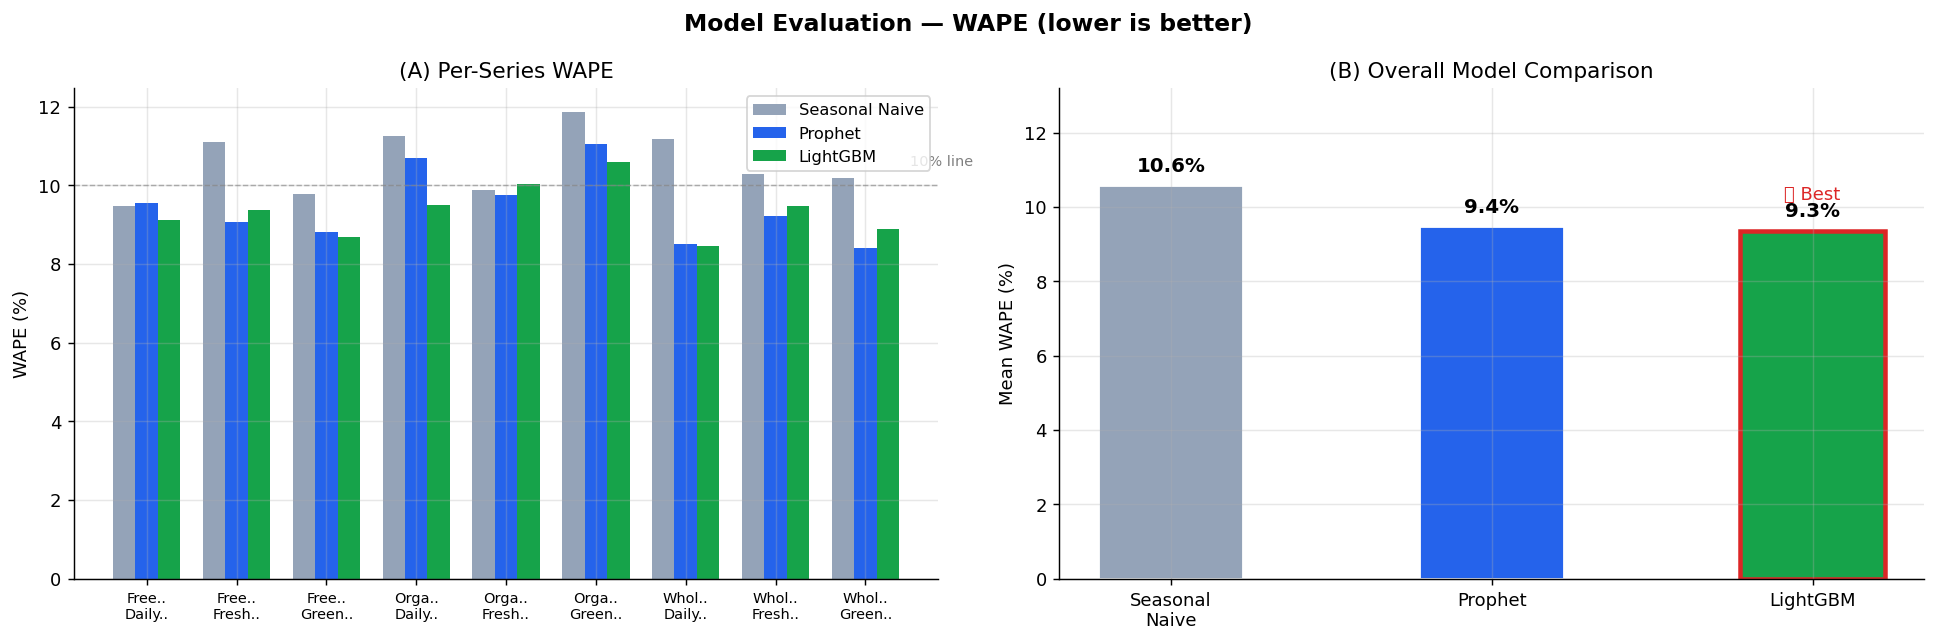

✅ Fig 4 saved


In [11]:
# ─────────────────────────────────────────────
#  CELL 10 — Model Comparison: WAPE Bar Chart
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Model Evaluation — WAPE (lower is better)", fontsize=13, fontweight="bold")

# ── (A) Per-series WAPE comparison ──
ax = axes[0]
series_labels = [f"{s[:4]}..\n{m[:5]}.." for s, m in SERIES]
x = np.arange(len(SERIES))
w = 0.25

naive_scores  = [results_naive.get((s,m), {}).get("wape", np.nan)  * 100 for s,m in SERIES]
prophet_scores= [results_prophet.get((s,m), {}).get("wape", np.nan)* 100 for s,m in SERIES]
lgbm_scores   = [results_lgbm.get((s,m), {}).get("wape", np.nan)   * 100 for s,m in SERIES]

ax.bar(x - w,   naive_scores,   w, label="Seasonal Naive", color="#94A3B8")
ax.bar(x,       prophet_scores, w, label="Prophet",        color="#2563EB")
ax.bar(x + w,   lgbm_scores,   w, label="LightGBM",       color="#16A34A")
ax.set_xticks(x)
ax.set_xticklabels(series_labels, fontsize=8)
ax.set_ylabel("WAPE (%)")
ax.set_title("(A) Per-Series WAPE")
ax.legend(fontsize=9)
ax.axhline(y=10, color="grey", ls="--", lw=0.8, alpha=0.6)
ax.text(len(SERIES) - 0.5, 10.5, "10% line", fontsize=8, color="grey")

# ── (B) Mean WAPE summary ──
ax = axes[1]
models_names  = ["Seasonal\nNaive", "Prophet", "LightGBM"]
mean_wapes    = [naive_wape * 100, prophet_wape * 100, lgbm_wape * 100]
bar_colors    = ["#94A3B8", "#2563EB", "#16A34A"]

bars = ax.bar(models_names, mean_wapes, color=bar_colors, width=0.45, edgecolor="white")
for bar, val in zip(bars, mean_wapes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f"{val:.1f}%", ha="center", va="bottom", fontweight="bold", fontsize=11)
ax.set_ylabel("Mean WAPE (%)")
ax.set_title("(B) Overall Model Comparison")
ax.set_ylim(0, max(mean_wapes) * 1.25)

best_idx = int(np.argmin(mean_wapes))
bars[best_idx].set_edgecolor("#DC2626")
bars[best_idx].set_linewidth(2.5)
ax.text(best_idx, mean_wapes[best_idx] + max(mean_wapes)*0.08,
        "⭐ Best", ha="center", fontsize=10, color="#DC2626")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "04_model_comparison.png", bbox_inches="tight")
plt.show()
print("✅ Fig 4 saved")

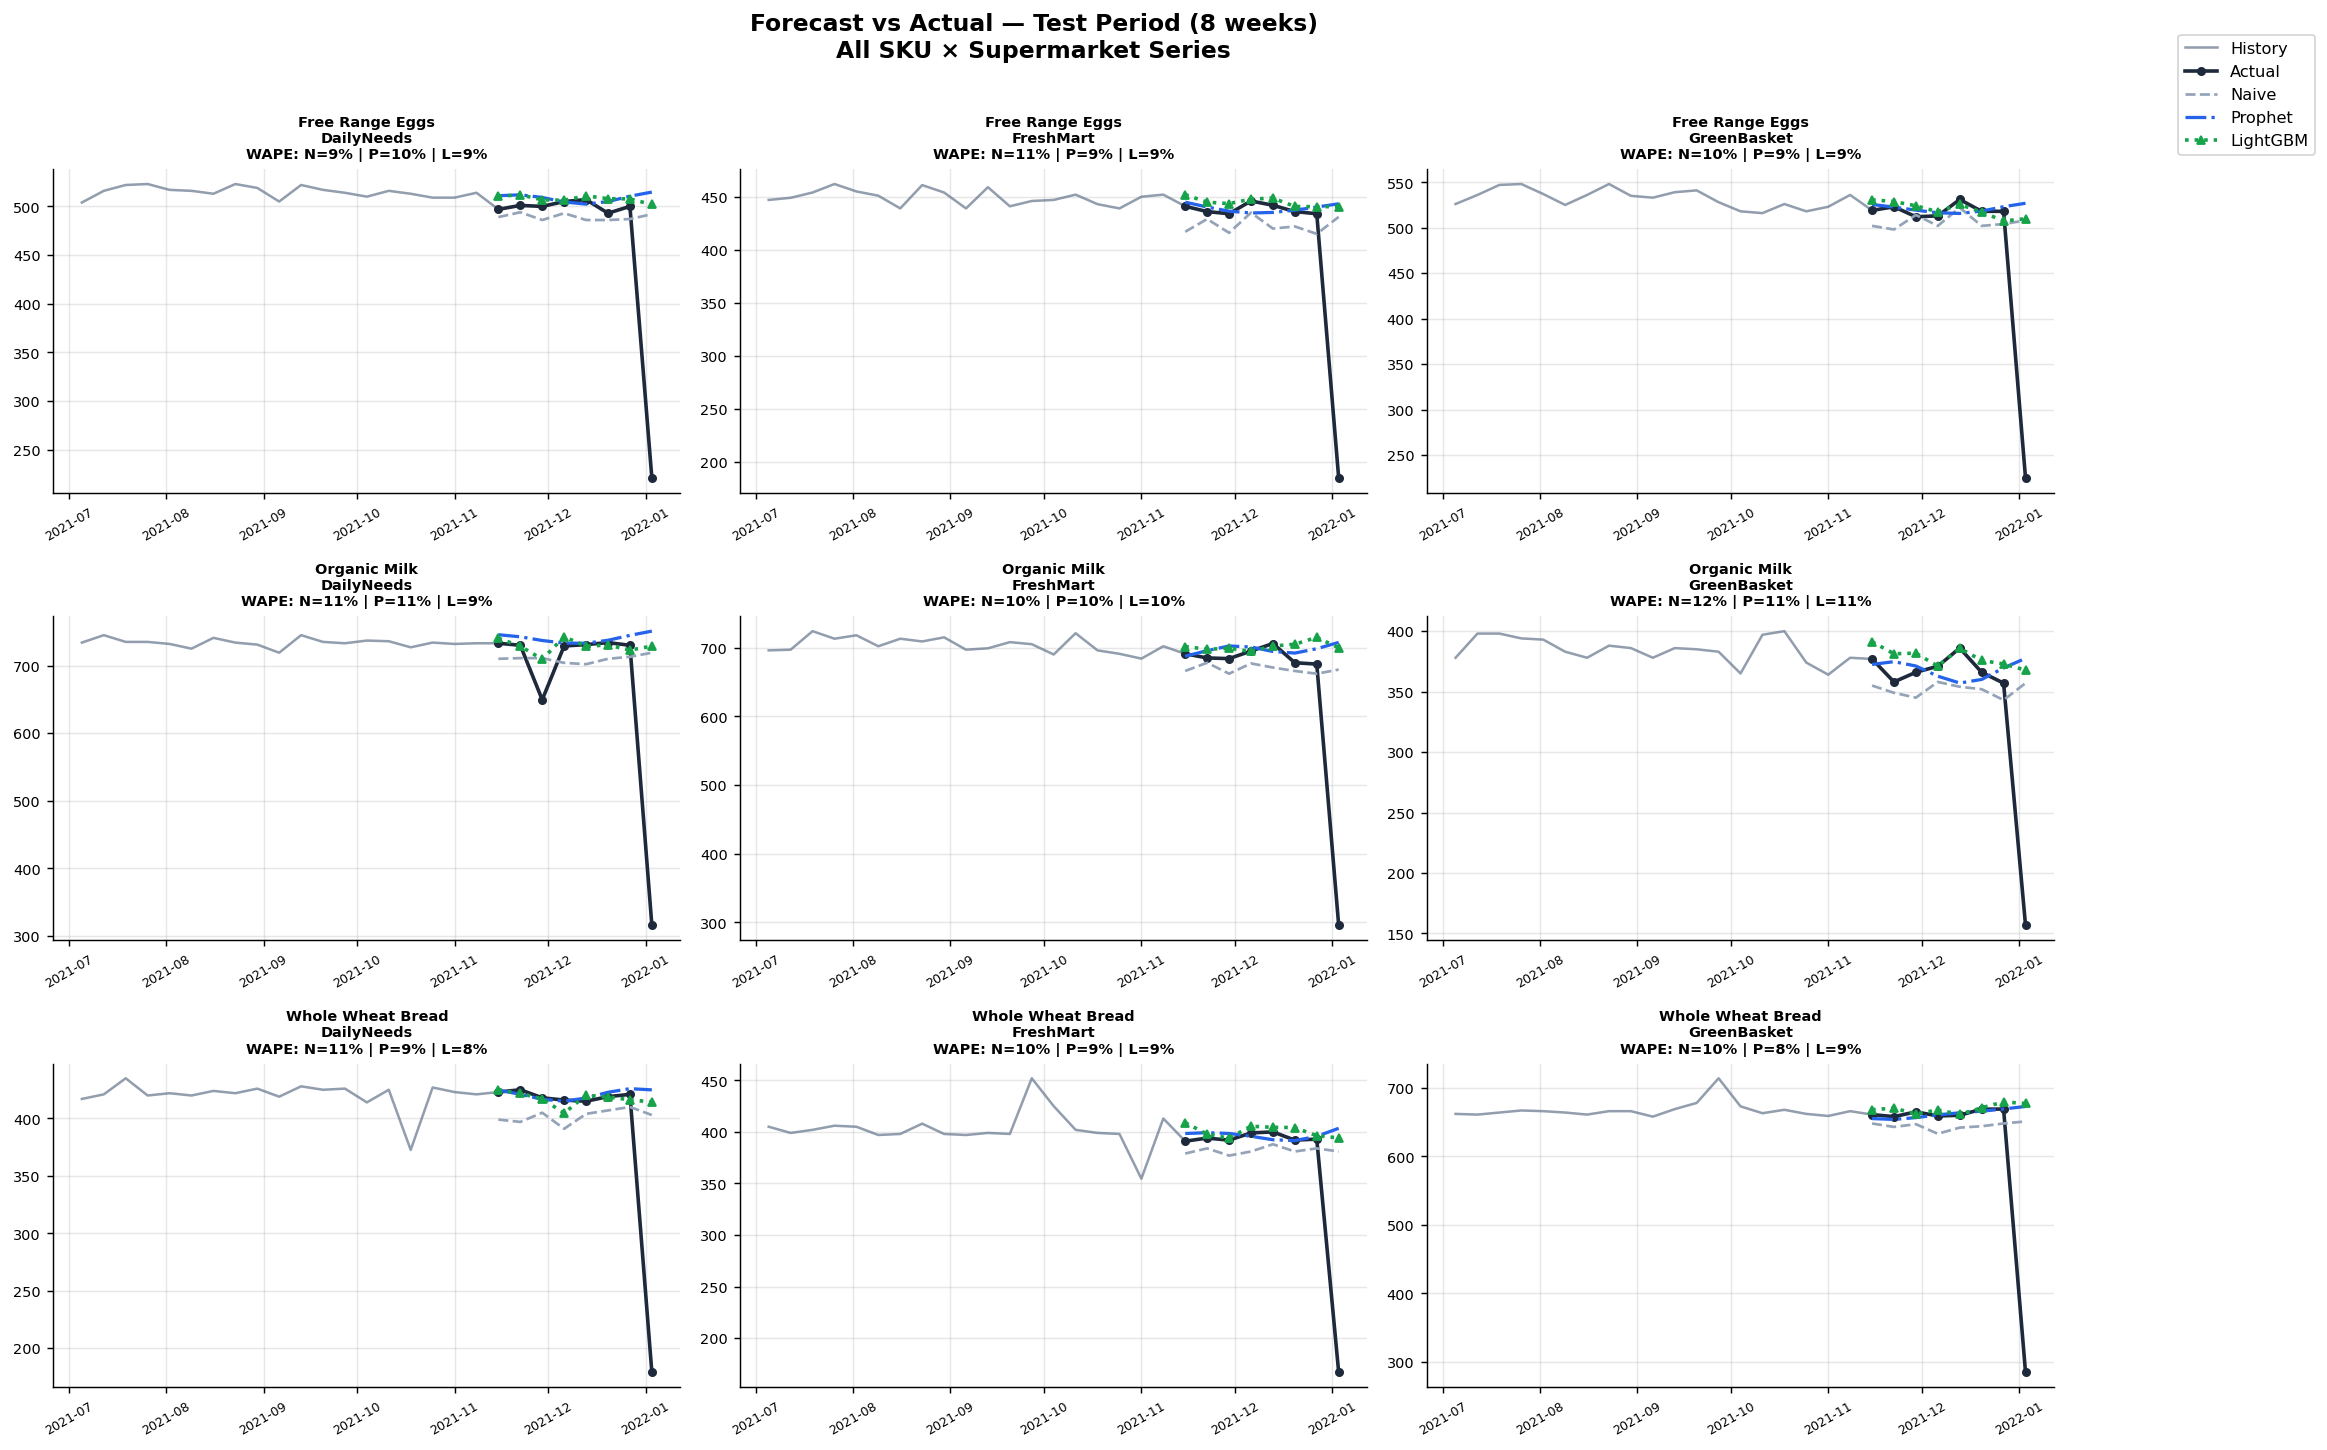

✅ Fig 5 saved


In [12]:
# ─────────────────────────────────────────────
#  CELL 11 — Forecast vs Actual: All 9 Series
# ─────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(16, 11))
fig.suptitle("Forecast vs Actual — Test Period (8 weeks)\nAll SKU × Supermarket Series",
             fontsize=13, fontweight="bold", y=1.01)

for ax, (sku, market) in zip(axes.flatten(), SERIES):
    s = weekly[(weekly["sku"] == sku) & (weekly["supermarket"] == market)].sort_values("week")
    _, test = split_series(s)

    # Plot last 20 weeks of history + 8-week test
    history = s[s["week"] <= test["week"].min()].tail(20)
    ax.plot(history["week"], history["demand"],
            lw=1.4, color="#64748B", alpha=0.7, label="History")
    ax.plot(test["week"], test["demand"],
            lw=2, color="#1E293B", marker="o", ms=4, label="Actual")

    # Naive
    nd = results_naive.get((sku, market), {})
    if nd:
        ax.plot(test["week"].values[:len(nd["preds"])], nd["preds"],
                lw=1.5, color="#94A3B8", linestyle="--", label="Naive")

    # Prophet
    pd_ = results_prophet.get((sku, market), {})
    if pd_:
        ax.plot(test["week"].values[:len(pd_["preds"])], pd_["preds"],
                lw=1.8, color="#2563EB", linestyle="-.", label="Prophet")

    # LightGBM
    ld = results_lgbm.get((sku, market), {})
    if ld:
        ax.plot(ld["weeks"][:len(ld["preds"])], ld["preds"],
                lw=2, color="#16A34A", linestyle=":", marker="^", ms=4, label="LightGBM")

    # WAPE annotations
    n_wape = nd.get("wape", np.nan)
    p_wape = pd_.get("wape", np.nan)
    l_wape = ld.get("wape", np.nan)
    ax.set_title(
        f"{sku}\n{market}\n"
        f"WAPE: N={n_wape*100:.0f}% | P={p_wape*100:.0f}% | L={l_wape*100:.0f}%",
        fontsize=8, fontweight="bold"
    )
    ax.tick_params(axis="x", rotation=30, labelsize=7)
    ax.tick_params(axis="y", labelsize=8)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right",
           bbox_to_anchor=(1.12, 1.0), fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "05_forecast_vs_actual.png", bbox_inches="tight")
plt.show()
print("✅ Fig 5 saved")

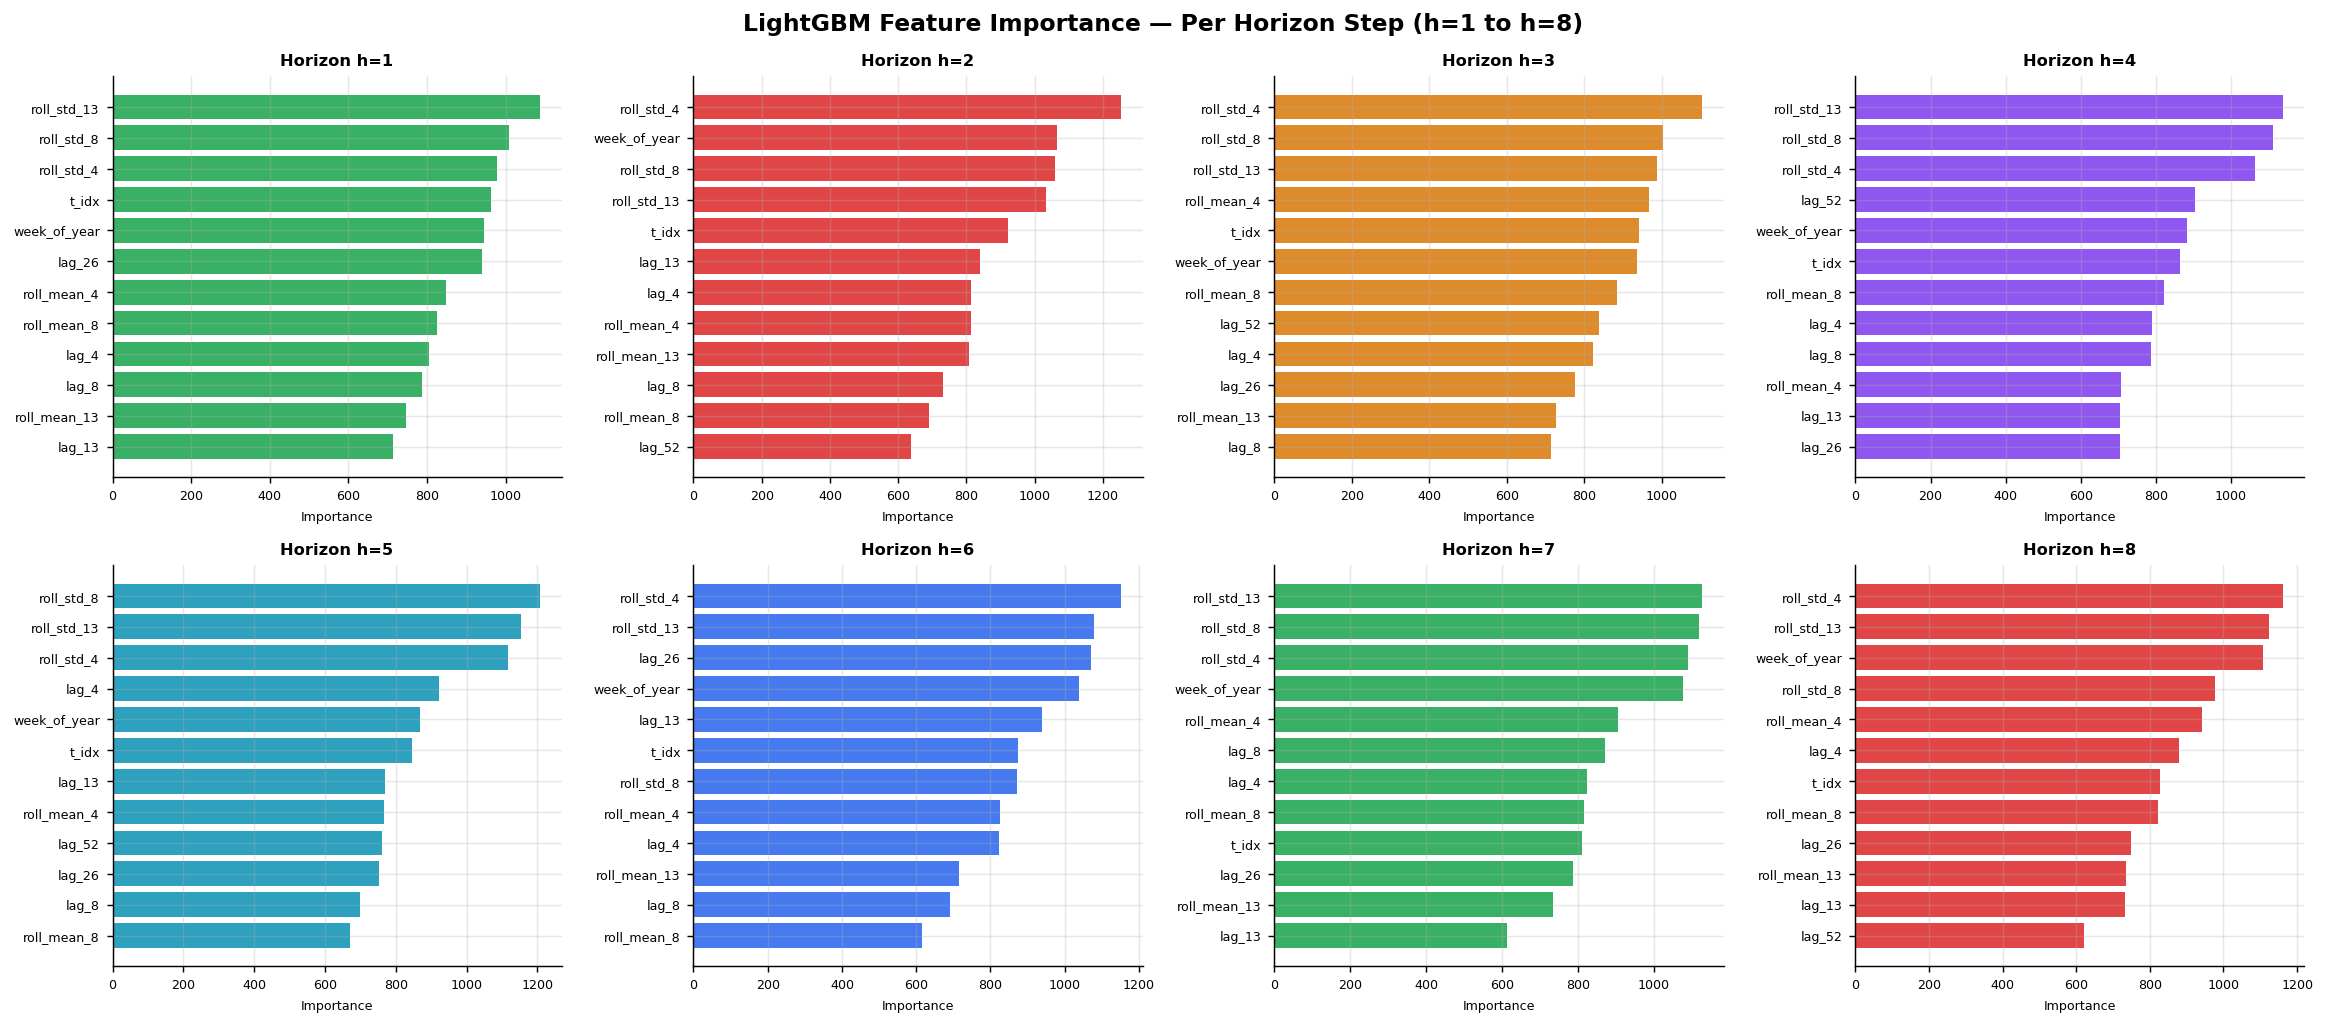

✅ Fig 6 saved


In [13]:
# ─────────────────────────────────────────────
#  CELL 12 — LightGBM Feature Importance
# ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("LightGBM Feature Importance — Per Horizon Step (h=1 to h=8)",
             fontsize=13, fontweight="bold")

for h, ax in enumerate(axes.flatten(), start=1):
    model, fcols = lgb_models[h]
    imp = pd.Series(model.feature_importances_, index=fcols).nlargest(12)
    imp_rev = imp[::-1]
    ax.barh(imp_rev.index, imp_rev.values, color=PALETTE[h % len(PALETTE)], alpha=0.85)
    ax.set_title(f"Horizon h={h}", fontsize=9, fontweight="bold")
    ax.tick_params(axis="y", labelsize=7)
    ax.tick_params(axis="x", labelsize=7)
    ax.set_xlabel("Importance", fontsize=7)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "06_lgbm_feature_importance.png", bbox_inches="tight")
plt.show()
print("✅ Fig 6 saved")

In [14]:
# ─────────────────────────────────────────────
#  CELL 13 — Summary Table
# ─────────────────────────────────────────────
rows = []
for sku, market in SERIES:
    rows.append({
        "SKU"         : sku,
        "Supermarket" : market,
        "Naive WAPE"  : f"{results_naive.get((sku,market),{}).get('wape',np.nan)*100:.1f}%",
        "Prophet WAPE": f"{results_prophet.get((sku,market),{}).get('wape',np.nan)*100:.1f}%",
        "LightGBM WAPE":f"{results_lgbm.get((sku,market),{}).get('wape',np.nan)*100:.1f}%",
    })

summary = pd.DataFrame(rows)
summary.loc[len(summary)] = {
    "SKU"          : "── MEAN ──",
    "Supermarket"  : "",
    "Naive WAPE"   : f"{naive_wape*100:.1f}%",
    "Prophet WAPE" : f"{prophet_wape*100:.1f}%",
    "LightGBM WAPE": f"{lgbm_wape*100:.1f}%",
}

print("\n" + "="*70)
print("FINAL RESULTS SUMMARY")
print("="*70)
print(summary.to_string(index=False))
print("="*70)

best_model = ["Seasonal Naive","Prophet","LightGBM"][
    int(np.argmin([naive_wape, prophet_wape, lgbm_wape]))
]
print(f"\n Best model: {best_model} with WAPE={min(naive_wape,prophet_wape,lgbm_wape)*100:.1f}%")
print(f"\n All plots saved to: {OUTPUT_DIR}")


FINAL RESULTS SUMMARY
              SKU Supermarket Naive WAPE Prophet WAPE LightGBM WAPE
  Free Range Eggs  DailyNeeds       9.5%         9.5%          9.1%
  Free Range Eggs   FreshMart      11.1%         9.1%          9.4%
  Free Range Eggs GreenBasket       9.8%         8.8%          8.7%
     Organic Milk  DailyNeeds      11.2%        10.7%          9.5%
     Organic Milk   FreshMart       9.9%         9.7%         10.0%
     Organic Milk GreenBasket      11.9%        11.1%         10.6%
Whole Wheat Bread  DailyNeeds      11.2%         8.5%          8.4%
Whole Wheat Bread   FreshMart      10.3%         9.2%          9.5%
Whole Wheat Bread GreenBasket      10.2%         8.4%          8.9%
       ── MEAN ──                  10.6%         9.4%          9.3%

 Best model: LightGBM with WAPE=9.3%

 All plots saved to: /kaggle/working


In [15]:
pip install onnxmltools lightgbm onnxruntime

Note: you may need to restart the kernel to use updated packages.


In [16]:
# %%
# ─────────────────────────────────────────────
#  CELL 14 — Save LightGBM models → ONNX
#  (8 models, one per horizon step h=1..8)
# ─────────────────────────────────────────────
# pip install onnxmltools onnxruntime

import json
import onnxmltools
from onnxmltools.convert import convert_lightgbm
from onnxmltools.utils import save_model
from onnxruntime import InferenceSession
from pathlib import Path

SAVE_DIR = Path("saved_models")
SAVE_DIR.mkdir(exist_ok=True)

feature_cols = lgb_models[1][1]
n_features   = len(feature_cols)

for h, (model, fcols) in lgb_models.items():
    onnx_model = convert_lightgbm(
        model,
        name          = f"demand_forecast_h{h}",
        initial_types = [("input", onnxmltools.convert.common.data_types.FloatTensorType([None, n_features]))]
    )
    out_path = SAVE_DIR / f"lgbm_h{h}.onnx"
    save_model(onnx_model, str(out_path))
    print(f"  Saved h={h} → {out_path}")

# Save feature column names — critical for inference (ONNX is positional)
meta = {
    "feature_cols" : feature_cols,
    "horizon"      : HORIZON,
    "model_type"   : "lightgbm_direct_multistep",
    "metric"       : "WAPE",
    "wape"         : round(lgbm_wape, 4),
}
with open(SAVE_DIR / "lgbm_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print(f"\n✅ LightGBM ONNX models saved to {SAVE_DIR}/")
print(f"   Files: lgbm_h1.onnx ... lgbm_h{HORIZON}.onnx + lgbm_meta.json")

# ── Sanity check: ONNX output must match original LightGBM output ──
print("\n── ONNX Sanity Check ──")
sess_h1    = InferenceSession(str(SAVE_DIR / "lgbm_h1.onnx"))
input_name = sess_h1.get_inputs()[0].name

first_key  = list(results_lgbm.keys())[0]
sku0, mkt0 = first_key
sku_col0   = f"sku_{sku0}"
mkt_col0   = f"supermarket_{mkt0}"

sample_row = feat_df_full[
    (feat_df_full[sku_col0] == 1) &
    (feat_df_full[mkt_col0] == 1) &
    (feat_df_full["week"] <= global_cutoff)
].iloc[[-1]][feature_cols].fillna(0).astype("float32").values

raw_output = sess_h1.run(None, {input_name: sample_row})
# raw_output is a list of arrays; flatten to scalar regardless of shape
onnx_pred  = float(np.array(raw_output).flatten()[0])

lgbm_pred  = float(lgb_models[1][0].predict(
    pd.DataFrame(sample_row, columns=feature_cols)
)[0])

print(f"  Series  : {sku0} @ {mkt0}")
print(f"  LightGBM: {lgbm_pred:.2f}")
print(f"  ONNX    : {onnx_pred:.2f}")
print(f"  Match   : {'✅' if abs(onnx_pred - lgbm_pred) < 0.01 else '❌ MISMATCH'}")

  Saved h=1 → saved_models/lgbm_h1.onnx
  Saved h=2 → saved_models/lgbm_h2.onnx
  Saved h=3 → saved_models/lgbm_h3.onnx
  Saved h=4 → saved_models/lgbm_h4.onnx
  Saved h=5 → saved_models/lgbm_h5.onnx
  Saved h=6 → saved_models/lgbm_h6.onnx
  Saved h=7 → saved_models/lgbm_h7.onnx
  Saved h=8 → saved_models/lgbm_h8.onnx

✅ LightGBM ONNX models saved to saved_models/
   Files: lgbm_h1.onnx ... lgbm_h8.onnx + lgbm_meta.json

── ONNX Sanity Check ──
  Series  : Free Range Eggs @ DailyNeeds
  LightGBM: 510.41
  ONNX    : 510.41
  Match   : ✅


In [17]:
# %%
# ─────────────────────────────────────────────
#  CELL 15 — Save Prophet models → pickle
#  (Prophet uses Stan internally — no ONNX support)
# ─────────────────────────────────────────────
import pickle

prophet_dir = SAVE_DIR / "prophet"
prophet_dir.mkdir(exist_ok=True)

# Re-train on FULL data (train + test) so production model
# has seen as much history as possible before saving
print("Re-training Prophet on full data for production save...\n")

prophet_index = {}
for sku, market in SERIES:
    s = weekly[(weekly["sku"] == sku) & (weekly["supermarket"] == market)]
    df_full = s.rename(columns={"week": "ds", "demand": "y"})[["ds", "y", "is_promo"]]

    m = Prophet(
        yearly_seasonality      = True,
        weekly_seasonality      = False,
        daily_seasonality       = False,
        changepoint_prior_scale = 0.05,
        seasonality_prior_scale = 10.0,
    )
    m.add_regressor("is_promo")

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        m.fit(df_full)

    key      = f"{sku}__{market}".replace(" ", "_")
    pkl_path = prophet_dir / f"prophet_{key}.pkl"
    with open(pkl_path, "wb") as f:
        pickle.dump(m, f)

    prophet_index[key] = str(pkl_path)
    print(f"  Saved → {pkl_path.name}")

# Save an index so the inference helper can locate models by key
with open(prophet_dir / "prophet_index.json", "w") as f:
    json.dump(prophet_index, f, indent=2)

print(f"\n✅ Prophet models saved to {prophet_dir}/")
print( "   Load with: pickle.load(open('prophet_<sku>__<market>.pkl', 'rb'))")

08:48:19 - cmdstanpy - INFO - Chain [1] start processing
08:48:19 - cmdstanpy - INFO - Chain [1] done processing


Re-training Prophet on full data for production save...



08:48:19 - cmdstanpy - INFO - Chain [1] start processing
08:48:19 - cmdstanpy - INFO - Chain [1] done processing


  Saved → prophet_Free_Range_Eggs__DailyNeeds.pkl


08:48:19 - cmdstanpy - INFO - Chain [1] start processing
08:48:19 - cmdstanpy - INFO - Chain [1] done processing
08:48:19 - cmdstanpy - INFO - Chain [1] start processing
08:48:19 - cmdstanpy - INFO - Chain [1] done processing
08:48:19 - cmdstanpy - INFO - Chain [1] start processing


  Saved → prophet_Free_Range_Eggs__FreshMart.pkl
  Saved → prophet_Free_Range_Eggs__GreenBasket.pkl
  Saved → prophet_Organic_Milk__DailyNeeds.pkl


08:48:19 - cmdstanpy - INFO - Chain [1] done processing
08:48:20 - cmdstanpy - INFO - Chain [1] start processing


  Saved → prophet_Organic_Milk__FreshMart.pkl


08:48:20 - cmdstanpy - INFO - Chain [1] done processing
08:48:20 - cmdstanpy - INFO - Chain [1] start processing
08:48:20 - cmdstanpy - INFO - Chain [1] done processing
08:48:20 - cmdstanpy - INFO - Chain [1] start processing
08:48:20 - cmdstanpy - INFO - Chain [1] done processing
08:48:20 - cmdstanpy - INFO - Chain [1] start processing
08:48:20 - cmdstanpy - INFO - Chain [1] done processing


  Saved → prophet_Organic_Milk__GreenBasket.pkl
  Saved → prophet_Whole_Wheat_Bread__DailyNeeds.pkl
  Saved → prophet_Whole_Wheat_Bread__FreshMart.pkl
  Saved → prophet_Whole_Wheat_Bread__GreenBasket.pkl

✅ Prophet models saved to saved_models/prophet/
   Load with: pickle.load(open('prophet_<sku>__<market>.pkl', 'rb'))


In [ ]:
# %%
# ─────────────────────────────────────────────
#  CELL 16 — Write inference helper script
#  Drop saved_models/demand_forecast_inference.py
#  into your FastAPI project — no training deps needed
# ─────────────────────────────────────────────

INFERENCE_CODE = '''"""
demand_forecast_inference.py
────────────────────────────
Standalone inference module. Only needs:
    pip install onnxruntime prophet pandas numpy

No lightgbm package required at runtime for the ONNX path.

FastAPI example
---------------
from demand_forecast_inference import forecast_lgbm, forecast_prophet

@app.get("/forecast/lgbm")
def lgbm_endpoint(sku: str, supermarket: str, ref_week: str):
    preds = forecast_lgbm(sku, supermarket, ref_week, is_promo=[0]*8)
    return {"weeks": preds}

@app.get("/forecast/prophet")
def prophet_endpoint(sku: str, supermarket: str, ref_week: str):
    df = forecast_prophet(sku, supermarket, ref_week, is_promo=[0]*8)
    return df.to_dict(orient="records")
"""

import json
import pickle
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from onnxruntime import InferenceSession

# ── Config ───────────────────────────────────────────────────────────────────
MODEL_DIR = Path(__file__).parent          # same folder as this script
HORIZON   = 8

SKUS    = ["Free Range Eggs", "Organic Milk", "Whole Wheat Bread"]
MARKETS = ["DailyNeeds", "FreshMart", "GreenBasket"]

# Training origin week — used to compute the t_idx feature
T0 = pd.Timestamp("2019-01-07")

# ── Load LightGBM ONNX sessions once at import time ──────────────────────────
with open(MODEL_DIR / "lgbm_meta.json") as f:
    _META = json.load(f)

FEATURE_COLS   = _META["feature_cols"]
LGBM_SESSIONS  = {
    h: InferenceSession(str(MODEL_DIR / f"lgbm_h{h}.onnx"))
    for h in range(1, HORIZON + 1)
}


# ── Feature builder ───────────────────────────────────────────────────────────
def _build_row(sku, supermarket, ref_week, h, is_promo_h, history):
    """
    Build a single float32 feature vector for horizon h.

    Parameters
    ----------
    ref_week   : str | Timestamp   last observed Monday
    h          : int               horizon step (1-8)
    is_promo_h : int               1 if the target week has a promotion
    history    : pd.Series         index=Timestamp (weekly), values=demand
                                   Pass an empty Series if unavailable —
                                   lag/rolling features will default to 0.
    """
    ref         = pd.Timestamp(ref_week)
    target_week = ref + pd.Timedelta(weeks=h)

    row = {
        "is_promo"    : int(is_promo_h),
        "week_of_year": int(target_week.isocalendar()[1]),
        "month"       : target_week.month,
        "quarter"     : (target_week.month - 1) // 3 + 1,
        "year"        : target_week.year,
        "t_idx"       : int((target_week - T0) / pd.Timedelta(weeks=1)),
    }

    # Lag features — look back from ref_week
    history_sorted = history.sort_index()
    for lag in [4, 8, 13, 26, 52]:
        lag_date = ref - pd.Timedelta(weeks=lag - 1)
        idx = history_sorted.index.asof(lag_date) if len(history_sorted) else None
        row[f"lag_{lag}"] = float(history_sorted[idx]) if idx is not None else 0.0

    # Rolling stats — over recent history up to ref_week
    recent = history_sorted[history_sorted.index <= ref]
    for w in [4, 8, 13]:
        window = recent.tail(w)
        row[f"roll_mean_{w}"] = float(window.mean()) if len(window) > 0 else 0.0
        row[f"roll_std_{w}"]  = float(window.std())  if len(window) > 1 else 0.0

    # Entity dummies
    for s in SKUS:
        row[f"sku_{s}"] = int(s == sku)
    for m in MARKETS:
        row[f"supermarket_{m}"] = int(m == supermarket)

    vec = np.array([row.get(c, 0.0) for c in FEATURE_COLS], dtype=np.float32)
    return np.nan_to_num(vec, nan=0.0).reshape(1, -1)


# ── Public API ────────────────────────────────────────────────────────────────
def forecast_lgbm(
    sku         : str,
    supermarket : str,
    ref_week    : str,
    is_promo    : list,
    history     : pd.Series = None,
) -> list:
    """
    8-week demand forecast via LightGBM ONNX (no Python ML deps at runtime).

    Parameters
    ----------
    sku, supermarket : str
    ref_week         : str   ISO date of the last known week, e.g. "2021-09-06"
    is_promo         : list  length-8 binary flags (1 = promotion that week)
    history          : pd.Series  optional — index=Timestamp, values=weekly demand
                       Providing history enables accurate lag/rolling features.

    Returns
    -------
    list of 8 floats — weekly demand forecasts
    """
    if history is None:
        history = pd.Series(dtype=float)

    preds = []
    for h in range(1, HORIZON + 1):
        sess = LGBM_SESSIONS[h]
        X    = _build_row(sku, supermarket, ref_week, h, is_promo[h - 1], history)
        p    = sess.run(None, {sess.get_inputs()[0].name: X})[0][0]
        preds.append(round(max(0.0, float(p)), 2))

    return preds


def forecast_prophet(
    sku         : str,
    supermarket : str,
    ref_week    : str,
    is_promo    : list,
) -> pd.DataFrame:
    """
    8-week demand forecast via Prophet with confidence intervals.

    Returns
    -------
    pd.DataFrame — columns: [ds, yhat, yhat_lower, yhat_upper]
    """
    key      = f"{sku}__{supermarket}".replace(" ", "_")
    pkl_path = MODEL_DIR / "prophet" / f"prophet_{key}.pkl"

    with open(pkl_path, "rb") as f:
        model = pickle.load(f)

    future_weeks = [
        pd.Timestamp(ref_week) + pd.Timedelta(weeks=h)
        for h in range(1, HORIZON + 1)
    ]
    future = pd.DataFrame({
        "ds"      : future_weeks,
        "is_promo": [int(p) for p in is_promo],
    })

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        fc = model.predict(future)

    fc["yhat"] = fc["yhat"].clip(lower=0)
    return fc[["ds", "yhat", "yhat_lower", "yhat_upper"]].reset_index(drop=True)


# ── Self-test ─────────────────────────────────────────────────────────────────
if __name__ == "__main__":
    SKU    = "Organic Milk"
    MARKET = "DailyNeeds"
    WEEK   = "2021-09-06"
    PROMO  = [0, 0, 0, 1, 0, 0, 0, 0]

    print("── LightGBM (ONNX) ──")
    for h, p in enumerate(forecast_lgbm(SKU, MARKET, WEEK, PROMO), 1):
        print(f"  Week +{h}: {p:.1f} units")

    print("\\n── Prophet ──")
    print(forecast_prophet(SKU, MARKET, WEEK, PROMO).to_string(index=False))
'''

inference_path = SAVE_DIR / "demand_forecast_inference.py"
with open(inference_path, "w") as f:
    f.write(INFERENCE_CODE)

print(f"✅ Inference helper written → {inference_path}")
print("""
── Saved model layout ─────────────────────────────────────────────
saved_models/
├── lgbm_h1.onnx  …  lgbm_h8.onnx   ← LightGBM (ONNX)
├── lgbm_meta.json                   ← feature column order + WAPE
├── prophet/
│   ├── prophet_Organic_Milk__DailyNeeds.pkl
│   └── … (9 pkl files + prophet_index.json)
└── demand_forecast_inference.py     ← drop into your FastAPI app
───────────────────────────────────────────────────────────────────
Runtime deps (inference only):  onnxruntime  prophet  pandas  numpy
No lightgbm needed for the ONNX path.
""")